# Data Exploration & Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import sent_tokenize
import sklearn 

In [2]:
data_df = pd.read_csv('IMDB.csv')
print(f"data shape: {data_df.shape}")
print(f"data columns: {data_df.columns}")
print(f"data head: {data_df.head()}")
print(f"data info: {data_df.info()}")

data shape: (50000, 2)
data columns: Index(['review', 'sentiment'], dtype='str')
data head:                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB
data info: None


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


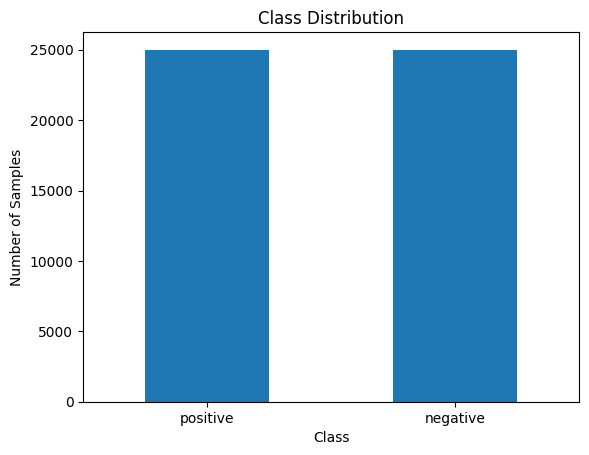

In [3]:
class_counts = data_df["sentiment"].value_counts()

print(class_counts)

# Plot distribution
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [4]:
(data_df["review"].str.strip() == "").sum()

np.int64(0)

In [5]:
data_duplicates = data_df.duplicated(subset="review", keep=False)
print(f"Number of duplicate reviews: {data_duplicates.sum()}")

check_on_same_reviews = data_df[data_duplicates].groupby("review").nunique()
print((check_on_same_reviews["sentiment"] > 1).sum())

Number of duplicate reviews: 824
0


In [6]:
data_df = data_df.drop_duplicates(subset="review", keep="first")
data_duplicates = data_df.duplicated(subset="review", keep=False)
print(f"Number of duplicate reviews: {data_duplicates.sum()}")

Number of duplicate reviews: 0


# Data Splitting

In [7]:
from sklearn.model_selection import train_test_split

X, y = data_df["review"], data_df["sentiment"]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42,stratify=y_temp)
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")


Training set size: 39665
Validation set size: 4958
Test set size: 4959


# Data Preprocessing

In [8]:
from nltk.tokenize import word_tokenize


def remove_br_tags(X):
    """Replace HTML line-break tags in a Series of review strings."""
    pattern = r"<br\s*/?\s*>"
    return X.str.replace(pattern, " ", regex=True)


def preprocess_reviews(X):
    """Accept a raw review string, list, or Series; return a Series of processed strings."""
    if isinstance(X, str):
        X = pd.Series([X])
    elif not isinstance(X, pd.Series):
        X = pd.Series(X)

    X = remove_br_tags(X)
    X = X.str.lower()
    X = X.apply(word_tokenize)
    return X.apply(" ".join)

In [9]:
X_train_text = preprocess_reviews(X_train)

X_sample = X_train.sample(n=1, random_state=42)
print(f"Original review: {X_sample.iloc[0]}")
print(f"Processed review: {X_train_text.loc[X_sample.index[0]]}")

Original review: Two escaped convicts step out of the woods and shoot two campers in the head. That's the first scene, and it made me wince, fearing what was in store. But by the end of the first half hour I was all swept up in the flood of images. Not because I cared in the least about any of the characters but because I was aghast at how execrable the film was and was curious to see how truly low it could sink.<br /><br />Frank (Remar) and Red (Woolvett) are the ex-inmates. After murdering the two innocent campers they plow through the woods and wangle their way into the isolated cabin of Dean Stockwell and his two sons, the attorney Keith and the estranged homosexual Behr. The escapees at first pretend their car has broken down and they need to use the phone, but they gradually reveal their identities.<br /><br />Well, it looks like familiar territory so far. "Desperate Hours," or "Funny Games" maybe. But -- hang on -- the gay son is in cahoots with the two. It seems that Stockwell,

# TF-IDF & Training


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression


def train_model(X_train_text, y_train):
    """Fit TF-IDF and logistic regression; return the model, encoders, and training matrix."""
    vectroizer2 = TfidfVectorizer()
    response = vectroizer2.fit_transform(X_train_text)
    print(f"Shape of the TF-IDF matrix: {response.shape}")
    print(f"Number of features: {len(vectroizer2.get_feature_names_out())}")

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    print(f"Label mapping: {dict(enumerate(label_encoder.classes_))}")

    model = LogisticRegression(max_iter=1000)
    model.fit(response, y_train_encoded)
    return model, vectroizer2, label_encoder, response

In [11]:
model, vectroizer2, label_encoder, response = train_model(X_train_text, y_train)

Shape of the TF-IDF matrix: (39665, 92941)
Number of features: 92941
Label mapping: {0: 'negative', 1: 'positive'}


# Inference & Evaluation Functions


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


def predict_reviews(X, model, vectroizer2, label_encoder):
    """Predict sentiment for one raw review or a collection of raw reviews."""
    X_text = preprocess_reviews(X)
    X_tfidf = vectroizer2.transform(X_text)
    y_pred_encoded = model.predict(X_tfidf)
    return label_encoder.inverse_transform(y_pred_encoded)


def evaluate_model(X, y, model, vectroizer2, label_encoder, set_name="Validation"):
    """Evaluate raw reviews against their string labels and return metrics and predictions."""
    y_pred = predict_reviews(X, model, vectroizer2, label_encoder)
    labels = label_encoder.classes_
    accuracy = accuracy_score(y, y_pred)
    report = classification_report(y, y_pred, labels=labels, zero_division=0)
    matrix = confusion_matrix(y, y_pred, labels=labels)

    print(f"{set_name} accuracy: {accuracy:.4f}")
    print(f"Classification report:\n{report}")
    ConfusionMatrixDisplay(matrix, display_labels=labels).plot(cmap="Blues")
    plt.title(f"{set_name} Confusion Matrix")
    plt.show()

    return {
        "accuracy": accuracy,
        "classification_report": classification_report(
            y, y_pred, labels=labels, output_dict=True, zero_division=0
        ),
        "confusion_matrix": matrix,
        "predictions": y_pred,
    }

# Validation Evaluation
Use validation results to compare future preprocessing choices and model settings.
The earlier accuracy measured on the training data was about 93.1%; it was not an unseen-data score.

Validation accuracy: 0.8959
Classification report:
              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      2470
    positive       0.88      0.91      0.90      2488

    accuracy                           0.90      4958
   macro avg       0.90      0.90      0.90      4958
weighted avg       0.90      0.90      0.90      4958



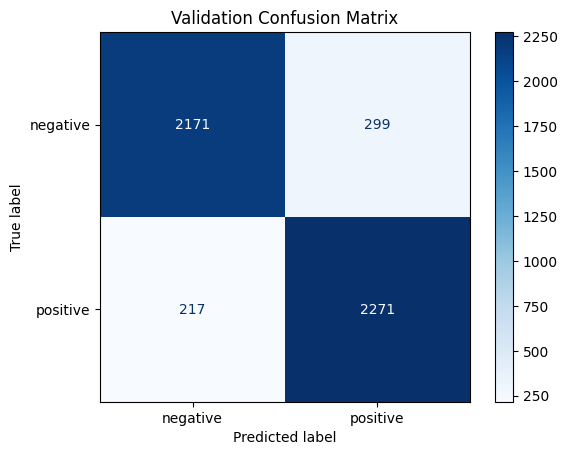

In [13]:
validation_results = evaluate_model(
    X_val, y_val, model, vectroizer2, label_encoder, set_name="Validation"
)

# Test Evaluation


Test accuracy: 0.8994
Classification report:
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      2470
    positive       0.89      0.91      0.90      2489

    accuracy                           0.90      4959
   macro avg       0.90      0.90      0.90      4959
weighted avg       0.90      0.90      0.90      4959



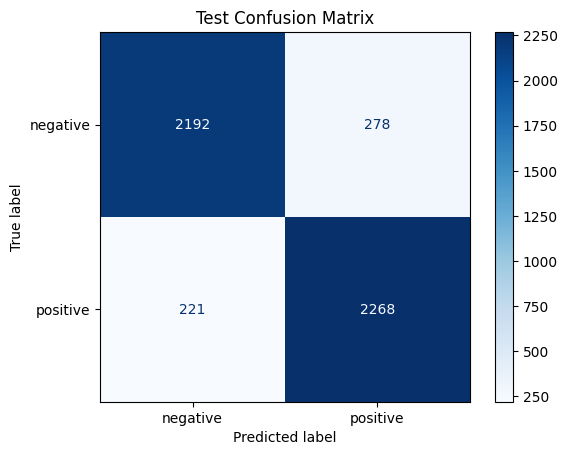

In [ ]:
test_results = evaluate_model(
    X_test, y_test, model, vectroizer2, label_encoder, set_name="Test"
)

# Predict New Reviews


In [15]:
new_reviews = [
    "I loved this movie! The acting was wonderful and the story kept me interested.",
    "This movie was boring.<br />I would not recommend it.",
]
new_predictions = predict_reviews(new_reviews, model, vectroizer2, label_encoder)
pd.DataFrame({"review": new_reviews, "predicted_sentiment": new_predictions})

,review,predicted_sentiment
0,I loved this movie! The acting was wonderful a...,positive
1,This movie was boring.<br />I would not recomm...,negative
